In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
def euler_to_rotation_matrix(pitch, yaw, roll):
    # Convert degrees to radians manually
    pitch = pitch * (torch.pi / 180)
    yaw = yaw * (torch.pi / 180)
    roll = roll * (torch.pi / 180)

    # Create rotation matrices for each axis
    Rx = torch.tensor([
        [1, 0, 0],
        [0, torch.cos(pitch), -torch.sin(pitch)],
        [0, torch.sin(pitch), torch.cos(pitch)]
    ])

    Ry = torch.tensor([
        [torch.cos(yaw), 0, torch.sin(yaw)],
        [0, 1, 0],
        [-torch.sin(yaw), 0, torch.cos(yaw)]
    ])

    Rz = torch.tensor([
        [torch.cos(roll), -torch.sin(roll), 0],
        [torch.sin(roll), torch.cos(roll), 0],
        [0, 0, 1]
    ])

    # Combine the rotations: R = Rz * Ry * Rx (order matters)
    R = torch.mm(Rz, torch.mm(Ry, Rx))
    return R

# Example Euler angles in degrees
pitch = torch.tensor(30.0)  # Rotation around X-axis
yaw = torch.tensor(45.0)    # Rotation around Y-axis
roll = torch.tensor(60.0)   # Rotation around Z-axis

# Get the rotation matrix [3,3]
rotation_matrix = euler_to_rotation_matrix(pitch, yaw, roll)
print("rotation matrix: \n",rotation_matrix)
# Set the translation vector [3,1]
translation_vector = torch.rand((3,1))
print("translation vector: \n", translation_vector)
c2w_R = rotation_matrix
c2w_T = translation_vector

rotation matrix: 
 tensor([[ 0.3536, -0.5732,  0.7392],
        [ 0.6124,  0.7392,  0.2803],
        [-0.7071,  0.3536,  0.6124]])
translation vector: 
 tensor([[0.8210],
        [0.9806],
        [0.7096]])


#### Test of ddim_splatfacto get_viewmat(optimized_camera_to_world)

In [6]:
# flip the z and y axes to align with gsplat conventions
R = c2w_R * torch.tensor([1, -1, -1])
print("R",R.shape)
R_inv = R[None].transpose(1,2)
print("R_inv",R_inv.shape)
print(c2w_T[None].shape)
T_inv = -torch.bmm(R_inv, c2w_T[None])
print("T_inv",T_inv)
print("T_inv",T_inv.squeeze(0).shape)

R torch.Size([3, 3])
R_inv torch.Size([1, 3, 3])
torch.Size([1, 3, 1])
T_inv tensor([[[-0.3890],
         [ 0.5052],
         [ 1.3163]]])
T_inv torch.Size([3, 1])


In [200]:
def get_transformed_vec(rot_matrix, trans_vec, original_vec):
    v_transformed = torch.mv(rot_matrix, original_vec) + trans_vec
    return v_transformed

In [201]:
# Original vector (starting vector)
original_vector = torch.tensor([1.0, 0.0, 0.0])
# Apply the rotation to the original vector
rotated_vector = torch.mv(rotation_matrix, original_vector)
rotated_vector_0 = torch.mv(R_inv, rotated_vector)
transformed_vector = get_transformed_vec(c2w_R,c2w_T.squeeze(), original_vector)
reversed_vector = get_transformed_vec(R_inv,T_inv.squeeze(), transformed_vector)
# Convert vectors to numpy for visualization
original_vector_np = original_vector.numpy()
rotated_vector_np = rotated_vector.numpy()
rotated_vector_0_np = rotated_vector_0.numpy()
transformed_vector_np = transformed_vector.numpy()
reversed_vector_np = reversed_vector.numpy()
print(original_vector)
print("\n transformed",transformed_vector_np,"\n reversed", reversed_vector_np)

tensor([1., 0., 0.])

 transformed [ 1.140687   1.5267001 -0.4989664] 
 reversed [9.9999994e-01 8.9406967e-08 5.9604645e-08]


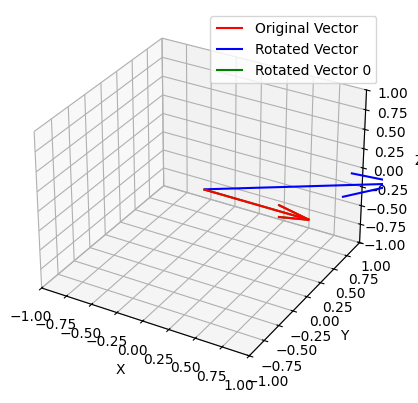

In [202]:
# Create a 3D plot to visualize the vectors
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
# Plot the original vector in red
ax.quiver(0, 0, 0, original_vector_np[0], original_vector_np[1], original_vector_np[2], color='r', label='Original Vector')

# # Plot the rotated vector in blue
# ax.quiver(0, 0, 0, rotated_vector_np[0], rotated_vector_np[1], rotated_vector_np[2], color='b', label='Rotated Vector')
# # Plot the rotated0 vector in green
# ax.quiver(0, 0, 0, rotated_vector_0_np[0], rotated_vector_0_np[1], rotated_vector_0_np[2], color='g', label='Rotated Vector 0')

# Plot the rotated vector in blue
ax.quiver(0, 0, 0, transformed_vector_np[0], transformed_vector_np[1], transformed_vector_np[2], color='b', label='Rotated Vector')
# Plot the rotated0 vector in green
ax.quiver(0, 0, 0, reversed_vector_np[0], reversed_vector_np[1], reversed_vector_np[2], color='g', label='Rotated Vector 0')

# Set labels for the axes
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# Add a legend
ax.legend()

# Display the plot
plt.show()

#### Test gs_sdf_loss convert_camera_from_gs_to_pytorch3d

In [14]:
T_inv.squeeze(2).unsqueeze(2).shape
# c2w_R.transpose(-1, -2)

torch.Size([1, 3, 1])

In [277]:
w2c = torch.zeros(1, 4, 4)
w2c[:, :3, :3] = c2w_R.transpose(-1, -2)
w2c_T =  -torch.bmm(c2w_R.transpose(-1,-2)[None], c2w_T[None])
w2c[:, :3, 3] =w2c_T.transpose(-1, -2)
w2c[:, 3, 3] = 1

cam2world = w2c.inverse()
cam2world[:, :3, 1:3] *= -1
cam2world = cam2world[:, :3, :]

# cam2world = torch.cat([c2w_R, c2w_T], dim=1)
print("cam2world",cam2world)
line = torch.Tensor([[0.0, 0.0, 0.0, 1.0]]).expand(1, -1, -1)
cam2world = torch.cat([cam2world, line], dim=1)
print("cam2world",cam2world)
world2cam = cam2world.inverse()
w2c_R, w2c_T = world2cam.split([3, 1], dim=-1)
print(f"w2c rotation:\n{w2c_R}, \nw2c translation:\n{w2c_T}")
R_unknown = w2c_R[:, :3].transpose(1, 2)# * torch.Tensor([-1.0, 1.0, -1])
T_unknown = w2c_T.squeeze(2)[:, :3]# * torch.Tensor([-1.0, 1.0, -1])
print(f"unknown rotation:\n{R_unknown}, \nunknown translation:\n{T_unknown}")

cam2world tensor([[[ 0.3536,  0.5732, -0.7392,  0.7871],
         [ 0.6124, -0.7392, -0.2803,  0.9143],
         [-0.7071, -0.3536, -0.6124,  0.2081]]])
cam2world tensor([[[ 0.3536,  0.5732, -0.7392,  0.7871],
         [ 0.6124, -0.7392, -0.2803,  0.9143],
         [-0.7071, -0.3536, -0.6124,  0.2081],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]])
w2c rotation:
tensor([[[ 3.5355e-01,  6.1237e-01, -7.0711e-01],
         [ 5.7322e-01, -7.3920e-01, -3.5355e-01],
         [-7.3920e-01, -2.8033e-01, -6.1237e-01],
         [-5.7003e-08, -5.1640e-08,  8.6003e-09]]]), 
w2c translation:
tensor([[[-0.6910],
         [ 0.2983],
         [ 0.9656],
         [ 1.0000]]])
unknown rotation:
tensor([[[ 0.3536,  0.5732, -0.7392],
         [ 0.6124, -0.7392, -0.2803],
         [-0.7071, -0.3536, -0.6124]]]), 
unknown translation:
tensor([[-0.6910,  0.2983,  0.9656]])


In [278]:
transformed_vector_sdf = get_transformed_vec(cam2world[:, :3, :3].squeeze(0),cam2world[:, :3, 3].squeeze(0),original_vector)
reversed_vector_sdf = get_transformed_vec(R_unknown.squeeze(0), T_unknown.transpose(-2,-1).squeeze(), transformed_vector_sdf* torch.Tensor([1.0, 1.0, 1]))

reversed_vector_sdf_np = reversed_vector_sdf.numpy()
print(reversed_vector_sdf_np)

[ 0.95624405  0.00812086 -0.07518286]


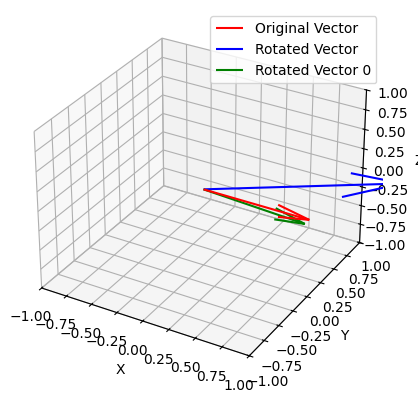

In [279]:
# Create a 3D plot to visualize the vectors
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
# Plot the original vector in red
ax.quiver(0, 0, 0, original_vector_np[0], original_vector_np[1], original_vector_np[2], color='r', label='Original Vector')

# Plot the rotated vector in blue
ax.quiver(0, 0, 0, transformed_vector_np[0], transformed_vector_np[1], transformed_vector_np[2], color='b', label='Rotated Vector')
# Plot the rotated0 vector in green
ax.quiver(0, 0, 0, reversed_vector_sdf_np[0], reversed_vector_sdf_np[1], reversed_vector_sdf_np[2], color='g', label='Rotated Vector 0')

# Set labels for the axes
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# Add a legend
ax.legend()

# Display the plot
plt.show()